# **Mestrado em Ciência de Dados - 2.º Ano**
**Aluno:** Miguel Loureiro | 2220134

**Instituição:** Universidade de Leiria e Oeste  

***Dissertação:*** Data Mining Aplicado à Transformação Digital de uma PME Portuguesa de E-commerce: Um Caso de Estudo Integrado

---

# **Notebook 6. Clustering | Hierárquico - Segmentação de Clientes por Portfólio de Produto**
*O presente notebook desenvolve a abordagem de clustering hierárquico aglomerativo aplicado à segmentação de clientes da PME em estudo, com base na composição do portfólio de produtos que são adquiridos.*

---

## **Contextualização do problema em estudo**

### **Problema de negócio**

Identificar segmentos comportamentais distintos de clientes de acordo com o portfólio de produtos que adquirem, complementando a segmentação K-Means do notebook anterior através de uma abordagem hierárquica aglomerativa. Este notebook auxilia na validação cruzada inter-método das duas segmentações de portfólio (K-Means × Hierárquico) e concentra-se na aplicação do algoritmo aglomerativo com linkage Ward, na interpretação do dendrograma e na determinação do k ótimo via Silhouette Score.

### **Formulação do problema de Clustering**

**Tarefa:** Clustering hierárquico aglomerativo, que permite criar uma hierarquia de fusões a partir de clientes individuais até um único cluster que contém todos os clientes.

**Dimensão:** Clientes recorrentes (com pelo menos 2 compras), contendo os 5.521 clientes provenientes do filtro aplicado no notebook anterior.

**Features:** 21 variáveis utilizadas no NB5, compostas pelas 15 variáveis de shares de gasto por Tipo de produto, pelas 3 variáveis de diversidade (`Num_Tipos`, `Num_Categorias`, `Num_Marcas`) e pelas 3 variáveis de padrão de consumo (`Frequency`, `Monetary`, `Ticket_Medio`).

**Métrica principal:** Silhouette Score médio, complementado pela análise qualitativa do dendrograma para a escolha do número de clusters.

### **Algoritmo aplicado**

| Algoritmo | Tipo | Justificação |
|---|---|---|
| **Clustering Hierárquico Aglomerativo (Ward linkage)** | Baseado em distância | Permite a visualização hierárquica das fusões através do dendrograma.|

A seleção do linkage Ward prende-se com a minimização da variância intra-cluster que lhe está associada, contribuindo para obter agrupamentos compactos e estatisticamente coerentes.

### **Boas práticas adotadas**

- **Determinação do k ótimo conjugando o dendrograma e o Silhouette Score**, sendo duas evidências complementares.
- **Comparação inter-método K-Means vs Hierárquico**, permitindo a validação cruzada da estrutura dos clusters identificados.

---

## **Estrutura do notebook**

1. Importação de bibliotecas
2. Carregamento do dataset de features
3. Normalização das features
4. Determinação do número ótimo de clusters
   - 4.1. Dendrograma
   - 4.2. Silhouette Score
5. Treino do modelo final
6. Caracterização dos clusters
   - 6.1. Perfil médio por cluster
   - 6.2. Heatmap dos perfis normalizados
   - 6.3. Dimensão de cada cluster
7. Visualização ilustrativa
8. Comparação K-Means vs Hierárquico
9. Exportação
10. Síntese

### **Outputs deste notebook**

- **`dataset_clusters_hierarquico.csv`** - atribuição de cluster por `Ref Cliente`.
- **`scaler_clusters_hc.pkl`** - `StandardScaler` ajustado.


## **1. Importação de bibliotecas**

O notebook é iniciado com a importação das bibliotecas necessárias à normalização das features, à aplicação do algoritmo hierárquico, ao cálculo do Silhouette Score, à visualização do dendrograma e à persistência do scaler.

In [ ]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

#Pré-processamento e algoritmo de clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#Construção e visualização do dendrograma
from scipy.cluster.hierarchy import linkage, dendrogram

## **2. Carregamento do dataset de features**

O carregamento dos dados é feito através do dataset filtrado produzido no notebook anterior. Este conjunto de dados contém os **5.521 clientes recorrentes** e as **21 variáveis** criadas anteriormente.

A justificação das features utilizadas (shares, diversidade e padrão de consumo) está documentada no notebook anterior.

In [ ]:
#Montar Drive e carregar o dataset de features produzido pelo NB5
from google.colab import drive
drive.mount('/content/drive')

#Dataset filtrado (5521 clientes recorrentes x 21 features) produzido pelo NB5
df_clusters = pd.read_csv(
    '/content/drive/MyDrive/dataset_features_clustering.csv',
    index_col=0   #Ref Cliente como índice
)

print(f'Dataset carregado: {df_clusters.shape}')
print(f'\nFeatures ({df_clusters.shape[1]}):')
for col in df_clusters.columns:
    print(f'  - {col}')

Mounted at /content/drive
Dataset carregado: (5521, 21)

Features (21):
  - share_Aves_
  - share_Cercas_Elécticas
  - share_Controlo_de_Pragas
  - share_Cães
  - share_Gatos
  - share_Incubadoras
  - share_Jardim_Agricultura
  - share_Material_de_Proteção
  - share_Moinhos_Depenadoras
  - share_Máquinas
  - share_Outros
  - share_Pecuária
  - share_Pombos
  - share_Roedores
  - share_Ulilidades
  - Num_Tipos
  - Num_Categorias
  - Num_Marcas
  - Frequency
  - Monetary
  - Ticket_Medio


## **3. Normalização das features**

As variáveis incluídas no dataset apresentam escalas distintas, sendo necessário aplicar `StandardScaler` de forma a uniformizar a sua escala (média = 0 e variância = 1).

In [ ]:
#Normalização das features - StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df_clusters)

print(f'Dimensão de X após normalização: {X.shape}')

Dimensão de X após normalização: (5521, 21)


## **4. Determinação do número ótimo de clusters**

O número de clusters a selecionar resulta da análise de duas abordagens complementares: o dendrograma (visualização hierárquica) e o Silhouette Score (métrica quantitativa).

### **4.1. Dendrograma**

A aplicação do método Ward permite criar o dendrograma, concentrando na visualização das 30 últimas fusões.

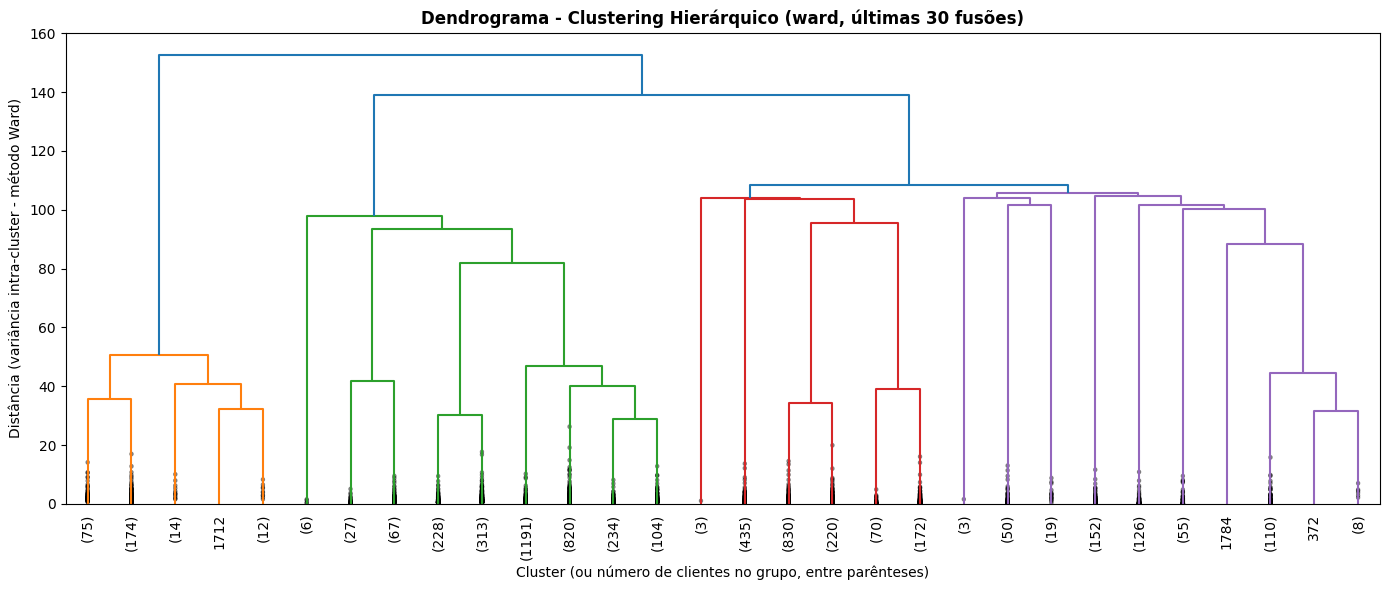

In [ ]:
#Calcular a matriz de linkage com o método Ward
matriz_linkage = linkage(X, method='ward')

#Dendrograma
plt.figure(figsize=(14, 6))
dendrogram(
    matriz_linkage,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
)
plt.title('Dendrograma - Clustering Hierárquico (ward, últimas 30 fusões)', fontweight='bold')
plt.xlabel('Cluster (ou número de clientes no grupo, entre parênteses)')
plt.ylabel('Distância (variância intra-cluster - método Ward)')
plt.tight_layout()
plt.show()

### **4.2. Silhouette Score**

Tal como foi aplicado no notebook anterior, é calculado o Silhouette Score médio para k entre 2 e 10.

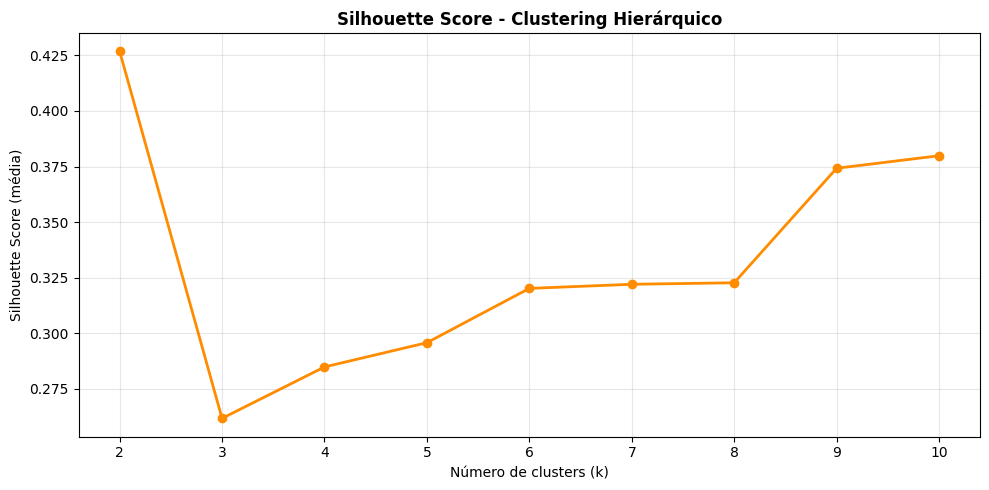


Valores numéricos do Silhouette Score:
  k=2: Silhouette = 0.4269
  k=3: Silhouette = 0.2617
  k=4: Silhouette = 0.2848
  k=5: Silhouette = 0.2957
  k=6: Silhouette = 0.3202
  k=7: Silhouette = 0.3220
  k=8: Silhouette = 0.3227
  k=9: Silhouette = 0.3742
  k=10: Silhouette = 0.3799

k com maior Silhouette: 2


In [ ]:
#Calcular Silhouette Score para k entre 2 e 10
ks = range(2, 11)
silhouettes = []

for k in ks:
    modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = modelo.fit_predict(X)
    silhouettes.append(silhouette_score(X, labels))

#Visualizar Silhouette
plt.figure(figsize=(10, 5))
plt.plot(list(ks), silhouettes, marker='o', linewidth=2, color='darkorange')
plt.title('Silhouette Score - Clustering Hierárquico', fontweight='bold')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score (média)')
plt.xticks(list(ks))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nValores numéricos do Silhouette Score:')
for k, s in zip(ks, silhouettes):
    print(f'  k={k}: Silhouette = {s:.4f}')

print(f'\nk com maior Silhouette: {list(ks)[silhouettes.index(max(silhouettes))]}')

**Interpretação dos critérios de seleção do k**

Os resultados obtidos foram os seguintes:

| k | Silhouette Score |
|---|---|
| 2 | 0,4269 |
| 3 | 0,2617 |
| 4 | 0,2848 |
| 5 | 0,2957 |
| **6** | **0,3202** |
| 7 | 0,3220 |
| 8 | 0,3227 |
| 9 | 0,3742 |
| 10 | 0,3799 |

A análise ao resultados obtidos revela que o maior valor de Silhouette Score acontece quando k=2 (0,4269), no entanto a divisão em apenas 2 clusters seria algo redutora e limitada.

A curva apresentada evidencia um padrão interessante caracterizado por uma queda acentuada entre k=2 (0,4269) e k=3 (0,2617), seguindo-se uma recuperação gradual até atingir uma constância de valores em k=6, k=7 e k=8. Contudo, a partir de k=9, o Silhouette aumenta (0,3742), mas a escolha por este número de clusters levaria a uma elevada fragmentação interna e à criação de subgrupos de dimensão reduzida. Desta forma, opta-se por 6 clusters, com um score de 0,3202, sendo o 2º maior aumento registado de Silhouette Score e permite uma distribuição de clusters mais ajustada sem a criação de clusters excessivamente pequenos. Este número de clusters consiste em menos um do que no K-Means.

## **5. Treino do modelo final**

Selecionados 6 clusters, procede-se ao treino do modelo final `AgglomerativeClustering(n_clusters=6, linkage='ward')`.

In [ ]:
#Definir k_otimo
k_otimo = 6

#Treinar AgglomerativeClustering final com k=6 e linkage Ward
modelo_hierarquico = AgglomerativeClustering(n_clusters=k_otimo, linkage='ward')
df_clusters['Cluster'] = modelo_hierarquico.fit_predict(X)

#Apresentar Silhouette final e distribuição
silhouette_final = silhouette_score(X, df_clusters['Cluster'])
print(f'Silhouette Score do modelo final (k={k_otimo}): {silhouette_final:.4f}')
print(f'\nDistribuição dos clientes por cluster:')
print(df_clusters['Cluster'].value_counts().sort_index())

Silhouette Score do modelo final (k=6): 0.3202

Distribuição dos clientes por cluster:
Cluster
0      72
1    1730
2    2990
3     276
4     301
5     152
Name: count, dtype: int64


**Análise da distribuição dos clusters**

O modelo hierárquico desenvolvido com 6 clusters apresenta a seguinte distribuição da base de 5.521 clientes recorrentes:

| Cluster | N | % | Dimensão |
|---|---|---|---|
| 0 | 72 | 1,30% | Nicho de pequena dimensão |
| 1 | 1.730 | 31,33% | Cluster de média dimensão |
| 2 | 2.990 | 54,16% | Maior cluster - mais de metade da base |
| 3 | 276 | 5,00% | Cluster de média-pequena dimensão |
| 4 | 301 | 5,45% | Cluster de média-pequena dimensão |
| 5 | 152 | 2,75% | Nicho de pequena dimensão |

A distribuição resultante é representada por uma estrutura maioritariamente concentrada em dois clusters (1 e 2), englobando, conjuntamente, cerca de 85% dos clientes recorrentes. Além disso, foram identificados dois clusters intermédios (3 e 4) e dois nichos de pequena dimensão (0 e 5).

## **6. Caracterização dos clusters**

A caracterização dos clusters é realizada através de uma interpretação do perfil médio em valores absolutos, do heatmap e da dimensão de cada cluster.

### **6.1. Perfil médio por cluster**

In [ ]:
#Perfil médio de cada cluster
perfil_clusters = df_clusters.groupby('Cluster').mean().round(3)
print('Perfil médio dos clusters:')
perfil_clusters

Perfil médio dos clusters:


,share_Aves_,share_Cercas_Elécticas,share_Controlo_de_Pragas,share_Cães,share_Gatos,share_Incubadoras,share_Jardim_Agricultura,share_Material_de_Proteção,share_Moinhos_Depenadoras,share_Máquinas,...,share_Pecuária,share_Pombos,share_Roedores,share_Ulilidades,Num_Tipos,Num_Categorias,Num_Marcas,Frequency,Monetary,Ticket_Medio
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.071,0.634,0.014,0.012,0.003,0.214,0.016,0.006,0.005,0.000,...,0.021,0.000,0.000,0.000,1.875,3.694,2.181,3.806,446.527,134.033
1,0.032,0.000,0.002,0.583,0.280,0.000,0.002,0.000,0.000,0.002,...,0.000,0.000,0.001,0.000,1.288,1.741,2.113,5.866,403.589,65.110
2,0.914,0.000,0.005,0.029,0.010,0.001,0.004,0.000,0.000,0.000,...,0.020,0.004,0.004,0.000,1.575,5.187,6.275,7.125,440.133,57.771
3,0.833,0.000,0.007,0.086,0.025,0.003,0.007,0.001,0.000,0.000,...,0.007,0.004,0.006,0.000,4.101,14.641,21.743,52.692,4460.379,93.160
4,0.023,0.000,0.421,0.018,0.005,0.000,0.357,0.159,0.000,0.000,...,0.002,0.000,0.003,0.009,1.432,1.917,1.728,3.080,172.118,57.285
5,0.036,0.000,0.004,0.015,0.014,0.000,0.002,0.000,0.000,0.000,...,0.001,0.000,0.925,0.000,1.546,2.875,2.336,8.039,421.513,47.323


### **6.2. Heatmap dos perfis**

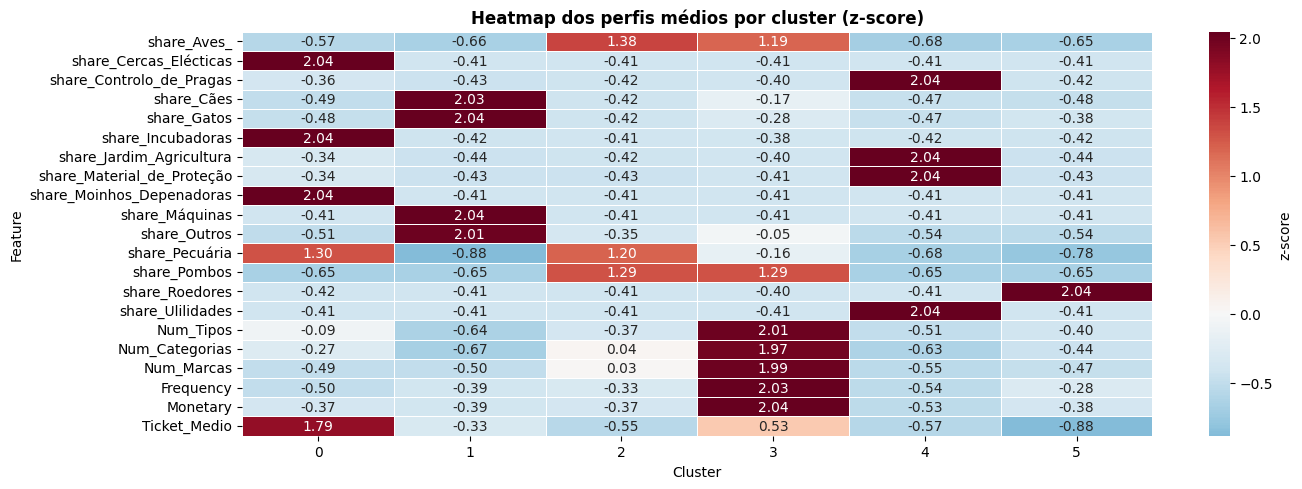

In [ ]:
#Calcular z-score por feature para o heatmap
perfil_normalizado = (perfil_clusters - perfil_clusters.mean()) / perfil_clusters.std()

#Heatmap dos perfis normalizados
plt.figure(figsize=(14, 5))
sns.heatmap(
    perfil_normalizado.T,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'z-score'}
)
plt.title('Heatmap dos perfis médios por cluster (z-score)', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### **6.3. Dimensão de cada cluster**

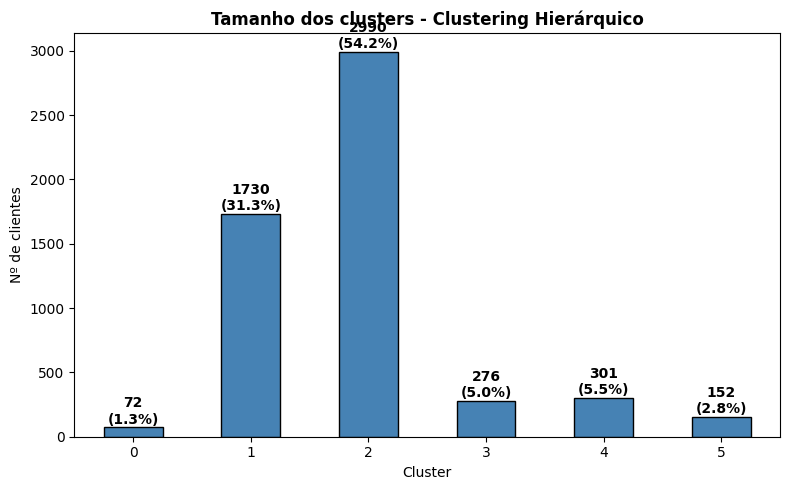


Proporção de clientes por cluster:
Cluster
0      1.3%
1    31.33%
2    54.16%
3      5.0%
4     5.45%
5     2.75%
Name: proportion, dtype: object


In [ ]:
#Calcular dimensões e proporções
tamanhos = df_clusters['Cluster'].value_counts().sort_index()
proporcoes = df_clusters['Cluster'].value_counts(normalize=True).sort_index() * 100

#Visualização em gráfico de barras
plt.figure(figsize=(8, 5))
ax = tamanhos.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Tamanho dos clusters - Clustering Hierárquico', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Nº de clientes')
plt.xticks(rotation=0)

for i, (n, p) in enumerate(zip(tamanhos.values, proporcoes.values)):
    ax.text(i, n + 30, f'{n}\n({p:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nProporção de clientes por cluster:')
print(df_clusters['Cluster'].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + '%')

**Interpretação dos clusters**

A análise do perfil médio, do heatmap e da dimensão de cada cluster permite identificar os seguintes perfis:

**Cluster 0 - "Compradores de Equipamento Especializado para Aves"** (n=72, 1,30%). Trata-se de um nicho profissional que apresenta um share de Cercas Elétricas elevado (0,634), assim como uma compra especializada de incubadoras e moinhos e depenadoras, não tendo sido identificado um cluster individual semelhante no K-Means. Este segmento é, igualmente, constituído por clientes ligados à pecuária com compras pouco frequentes, mas com um ticket médio bastante elevado em comparação aos restantes (134€).

**Cluster 1 - "Tutores de Cães e Gatos"** (n=1.730, 31,33%) - Aglomeração dos Tutores de cães e gatos, resultante de um share médio de, respetivamente, 0,583 e 0,280. Este cluster agrupa o que o K-Means separa em dois clusters distintos (*Clientes de Cães* - C1 + *Tutores de Gatos* - C5). Adicionalmente, regista-se um z-score elevado associado à compra de produtos do tipo Máquinas.

**Cluster 2 - "Avicultores Gerais"** (n=2.990, 54,16%) - Segmento de clientes predominante, sendo composto por um número significativo de clientes que compram produtos do tipo Aves, conforme comprovado pelo share de Aves elevado (share = 0,914). Este segmento é relevante, mas não integra os clientes com maior valor acrescentado para a empresa, pois não lhe está associado valores mais elevados de frequência média de compras (7 compras), valor médio gasto (440€) e ticket médio (57,77€).

**Cluster 3 - "Avicultores VIP / Potencial Champion"** (n=276, 5,00%) - Versão restrita do segmento VIP, representada por apenas 48% do Cluster 3 obtido no K-Means. Este cluster agrega os clientes com elevado share de Aves (core business da empresa) que se caracterizam por elevados valores de diversidade (Num_Tipos, Num_Categorias, Num_Marcas) e, mais relevante ainda, os clientes com elevada frequência de compra (52 compras), valor gasto (4.460€) e ticket médio (93,16€).

**Cluster 4 - "Clientes de Ambiente Rural"** (n=301, 5,45%) - Cluster heterogéneo distribuído por clientes que compram produtos dos tipos Controlo de Pragas (0,421), Jardim/Agricultura (0,357) e Material de Proteção (0,159). Esta distribuição evidencia que se trata de clientes associados à utilização de produtos em ambientes mais rurais e profissionais.

**Cluster 5 - "Tutores de Roedores"** (n=152, 2,75%) - Nicho especializado em tutores de pequenos roedores, assegurando uma correspondência com o K-Means quase perfeita (98% vem de C2).

## **7. Visualização - Scatter plot ilustrativo**

Segue-se a apresentação do Scatter plot, que permite visualizar as duas features `share_*` com maior variância.

Features escolhidas para o scatter: share_Aves_ vs share_Cães


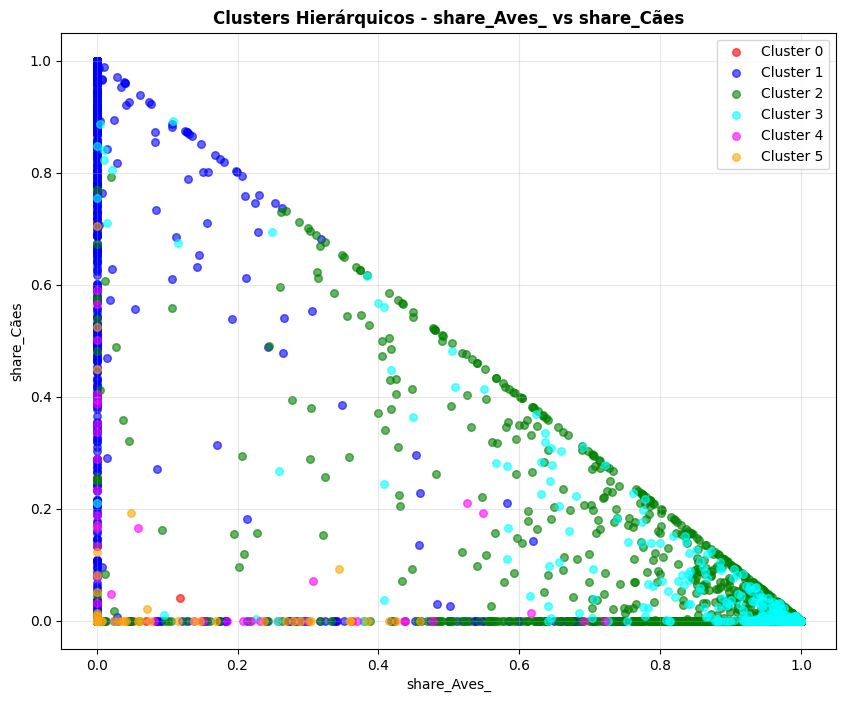

In [ ]:
#Escolher automaticamente as 2 features 'share_*' com maior variância
share_cols = [c for c in df_clusters.columns if c.startswith('share_')]
variancias = df_clusters[share_cols].var().sort_values(ascending=False)
col_x = variancias.index[0]
col_y = variancias.index[1]
print(f'Features escolhidas para o scatter: {col_x} vs {col_y}')

cores = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange',
         'purple', 'brown', 'pink', 'gray']

plt.figure(figsize=(10, 8))
for c in range(k_otimo):
    mask = df_clusters['Cluster'] == c
    plt.scatter(
        df_clusters.loc[mask, col_x],
        df_clusters.loc[mask, col_y],
        s=30, c=cores[c], label=f'Cluster {c}', alpha=0.6
    )
plt.title(f'Clusters Hierárquicos - {col_x} vs {col_y}', fontweight='bold')
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **Interpretação do scatter**

A visualização apresentada demonstra uma separação clara entre Avicultores Gerais (Cluster 2) e Tutores de Cães e Gatos (Cluster 1). Os restantes clusters caracterizados por uma elevada especialização, Tutores de Roedores (5), Equipamento Agrícola (0) e Clientes de Ambiente Rural (4) apresentam uma elevada concentração na proximidade da origem.

## **8. Comparação K-Means vs Hierárquico**

A comparabilidade cruzada entre os resultados obtidos no K-Means com a aplicação de Cluster Hierárquico permite avaliar a concordância inter-método, sendo realizada com recurso a uma tabela de contigência.

Clientes comparáveis (interseção): 5521

Tabela de contingência - K-Means vs Hierárquico
(número de clientes em cada combinação de clusters)
Cluster_Hierarquico   0     1     2    3    4    5  Total
Cluster_KMeans                                           
0                     6    61  2662    0   48    1   2778
1                    15  1167    34    0  134    2   1352
2                     0     0     1    0    1  149    151
3                     2    11   284  275    3    0    575
4                    49     0     0    1    0    0     50
5                     0   491     9    0    0    0    500
6                     0     0     0    0  115    0    115
Total                72  1730  2990  276  301  152   5521


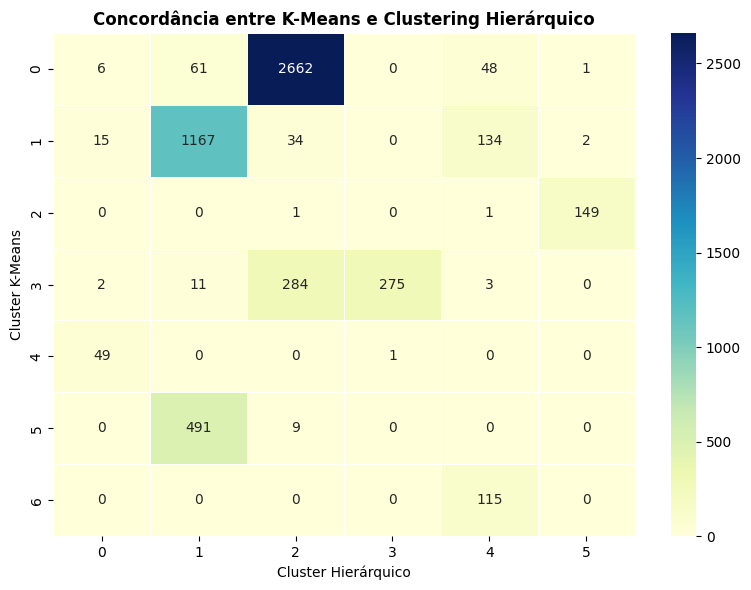

In [ ]:
#Carregar resultados do K-Means (NB5)
df_kmeans = pd.read_csv(
    '/content/drive/MyDrive/dataset_clusters_kmeans.csv',
    index_col=0
)

#Cruzar atribuições dos dois métodos
comparacao = pd.DataFrame({
    'Cluster_KMeans':      df_kmeans['Cluster'],
    'Cluster_Hierarquico': df_clusters['Cluster']
})

#Restringir à interseção dos dois universos
comparacao = comparacao.dropna().astype(int)
print(f'Clientes comparáveis (interseção): {len(comparacao)}')

#Tabela de contingência K-Means × Hierárquico
tabela_cruzada = pd.crosstab(
    comparacao['Cluster_KMeans'],
    comparacao['Cluster_Hierarquico'],
    margins=True,
    margins_name='Total'
)
print('\nTabela de contingência - K-Means vs Hierárquico')
print('(número de clientes em cada combinação de clusters)')
print(tabela_cruzada)

#Heatmap da tabela cruzada
tabela_sem_margens = pd.crosstab(
    comparacao['Cluster_KMeans'],
    comparacao['Cluster_Hierarquico']
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    tabela_sem_margens,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title('Concordância entre K-Means e Clustering Hierárquico', fontweight='bold')
plt.xlabel('Cluster Hierárquico')
plt.ylabel('Cluster K-Means')
plt.tight_layout()
plt.show()

### **Análise de concordância K-Means vs Hierárquico**

A tabela de contingência construída considerou os 5.521 clientes recorrentes em ambas as abordagens de clustering e permitiu extrair as seguintes interpretações:

| Arquétipo | K-Means (NB5) | Hierárquico (NB6) | Concordância |
|---|---|---|---|
| Avicultores Gerais | C0 (n=2.778) | C2 (n=2.990) | 2.662 / 2.778 = **95,8%** |
| Clientes de Cães | C1 (n=1.352) | parte de C1 | 1.167 / 1.352 = **86,3%** |
| Tutores de Roedores | C2 (n=151) | C5 (n=152) | 149 / 151 = **98,7%** |
| Avicultores VIP | C3 (n=575) | C3 (n=276) | 275 / 575 = **47,8%** |
| Compradores de Equipamento Agrícola | C4 (n=50) | C0 (n=72) | 49 / 50 = **98,0%** |
| Tutores de Gatos | C5 (n=500) | parte de C1 | 491 / 500 = **98,2%** |
| Compradores de Jardim/Agricultura | C6 (n=115) | parte de C4 | 115 / 115 = **100,0%** |

- Concordância elevada entre métodos: Os clusters dominantes e os nichos especializados apresentam níveis de concordância superiores a 85%, confirmando que o segmento chave da empresa (Aves) e os nichos profissionais são identificados de forma robusta em ambos os casos. No caso dos segmentos de tutores de cães e gatos, foram obtidos elevados níveis de concordância apesar da fusão destes dois segmentos verificada no método hierárquico, revelando que o perfil destes clientes permanece interpretável em ambos os métodos.

- Divergência no cluster dos Avicultores VIP: apenas 47,8% dos VIPs identificados pelo K-Means (575) são igualmente considerados VIPs no Hierárquico (276), 300 são reclassificados, entre os quais 284 VIPs são absorvidos pelo segmento de Avicultores Gerais do K-Means. Esta divergência revela que o limite entre avicultores VIP e clientes regulares avícolas é estatisticamente difuso, demonstrando uma maior exigência do K-Means na constituição do segmento de Avicultores VIP.

## **9. Exportação**

Finda a manipulação dos dados, são exportados dois outputs:

- **`dataset_clusters_hierarquico.csv`** - dataframe `df_clusters` com a coluna `Cluster` adicionada.
- **`scaler_clusters_hc.pkl`** - `StandardScaler` ajustado.

In [ ]:
#Exportar dataset com clusters atribuídos
df_clusters.to_csv('/content/drive/MyDrive/dataset_clusters_hierarquico.csv')
print('Dataset exportado: dataset_clusters_hierarquico.csv')

#Garantir que a pasta /modelos existe
os.makedirs('/content/drive/MyDrive/modelos', exist_ok=True)

#Persistir o scaler
joblib.dump(scaler, '/content/drive/MyDrive/modelos/scaler_clusters_hc.pkl')
print('Scaler guardado: scaler_clusters_hc.pkl')

Dataset exportado: dataset_clusters_hierarquico.csv
Scaler guardado: scaler_clusters_hc.pkl


## **10. Síntese**

O Clustering Hierárquico Aglomerativo com aplicação de linkage Ward segmentou a base de 5.521 clientes recorrentes em 6 grupos com perfis comportamentais distintos.

- **k=6 selecionado** com Silhouette de **0,3202**, embora não seja o maior valor de Silhouette registado, mas garante que a estrutura dos clusters não seja excessivamente reduzida ou elevada.

- **Estrutura altamente assimétrica** ao identificar dois clusters dominantes (Avicultores Gerais 54,2% e Tutores de Cães e Gatos 31,3%).

- **Validação inter-método K-Means × Hierárquico**, obtendo-se, na sua maioria, níveis de concordância superiores a 85% nos clusters core e nichos, excetuando-se o segmento de Avicultores VIP com um nível de concordância de 47,8%, traduzindo um limite ténue entre Avicultores VIP e clientes avícolas regulares.

Finda a abordagem de clustering associada ao portfólio de produto retratada no presente notebook e no anterior, no próximo notebook é desenvolvida a abordagem de ciclo de vida via RFM.